# Task 2: Predict Future Stock Prices

## Objective

Predict future stock closing prices using historical stock market data and Linear Regression.

In [1]:
import yfinance as yf
import pandas as pd

df = yf.download("AAPL", start="2022-01-01", end="2026-01-01")

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939713,178.790267,173.735885,173.853197,104487900
2022-01-04,175.681366,178.848915,175.114335,178.545850,99310400
2022-01-05,171.008286,176.140880,170.734548,175.593406,94537600
2022-01-06,168.153564,171.379770,167.801615,168.837907,96904000
2022-01-07,168.319763,170.245709,167.205258,169.023663,86709100


In [2]:
df.shape

(1003, 5)

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1003 entries, 2022-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1003 non-null   float64
 1   (High, AAPL)    1003 non-null   float64
 2   (Low, AAPL)     1003 non-null   float64
 3   (Open, AAPL)    1003 non-null   float64
 4   (Volume, AAPL)  1003 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.0 KB


In [4]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1003.000000,1003.000000,1003.000000,1003.000000,1.003000e+03
mean,189.695471,191.569283,187.639493,189.504209,6.461241e+07
std,37.459387,37.596478,37.264769,37.429276,2.783976e+07
min,122.933548,125.637653,122.097753,123.907026,1.791060e+07
25%,161.893341,163.127459,159.790947,161.515636,4.615660e+07
50%,182.731613,184.463969,181.130694,182.629378,5.652950e+07
75%,220.545509,222.783287,218.105038,219.969178,7.652195e+07
max,285.659271,288.084759,282.774617,285.669263,3.186799e+08


In [5]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

print(X.head())

Price             Open        High         Low     Volume
Ticker            AAPL        AAPL        AAPL       AAPL
Date                                                     
2022-01-03  173.853197  178.790267  173.735885  104487900
2022-01-04  178.545850  178.848915  175.114335   99310400
2022-01-05  175.593406  176.140880  170.734548   94537600
2022-01-06  168.837907  171.379770  167.801615   96904000
2022-01-07  169.023663  170.245709  167.205258   86709100


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

(802, 4)


In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 4)","[[0.33,0.34,0.33,0. ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.28]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[7.86e+08,1.63e+03,3.78e+01,3.34e+01]"


In [8]:
y_pred = model.predict(X_test)

y_pred[:5]

array([[215.43986068],
       [224.22109872],
       [206.24678463],
       [191.22106848],
       [183.7079032 ]])

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 1.3493198705303175
R2: 0.9978762749540203


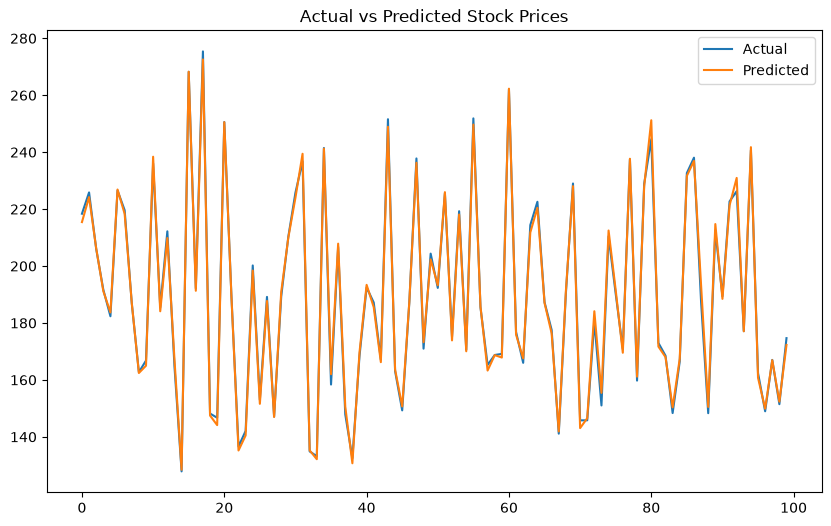

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(y_test.values[:100], label="Actual")

plt.plot(y_pred[:100], label="Predicted")

plt.legend()

plt.title("Actual vs Predicted Stock Prices")

plt.show()

## Findings

1. Historical Apple stock data was used.
2. Linear Regression model was trained.
3. The model successfully predicted stock closing prices.
4. Predicted prices closely followed actual prices.
5. The model achieved a good R² score.

## Conclusion

This project demonstrates how machine learning can be used to predict stock prices using historical market data. Linear Regression provided accurate predictions and showed strong correlation with actual stock prices.